In [1]:
import sys
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from hyperopt import fmin, tpe, hp, Trials
from scipy.integrate import solve_ivp
import warnings
warnings.filterwarnings("ignore")

In [2]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
# --------------- Import custom modules  --------------- #
from model.dualscale import PEMFC
from model.coefficients import *
from modules.signals import generate_step_load
from config.initialize import *
from config.settings import *

In [3]:
expdata_AST = pd.read_csv(project_root / "data" / "AST_SquareLoad.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'd:\\MFC2024\\data\\AST_SquareLoad.csv'

In [ ]:
# --- Global parameters ---
tstart     = 0.0      # start of each period                    [s]
tend       = 6.0    # end of each period                      [s]
i_low      = 0.002e4      # baseline current density                [A/m^2]
i_high     = 1.2e4    # plateau current density                 [A/m^2]
tau_switch = 1.5    # time (within a period) the ramp BEGINS  [s]
t_switch   = 1   # effective ramp duration                 [s]

step_load = generate_step_load(tstart, tend, i_low, i_high, tau_switch, t_switch)

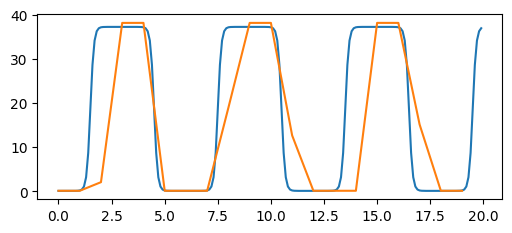

In [ ]:
plt.figure(figsize=(6, 2.4))
plt.plot(np.arange(0, 20., 0.1), [step_load(i)*31e-4 for i in np.arange(0, 20, 0.1)])
plt.plot(expdata_AST["I_LOAD_A"].iloc[60003:60023].tolist())

In [ ]:
operating_inputs = {'current_density': lambda x: 0.1e4, 'Tfc': 353.15, 
                                    'Pa_des': 1.8e5, 'Pc_des': 1.8e5,
                                    'Phi_a_des': 0.0, 'Phi_c_des': 0.85,
                                    'Sa': 1.2, 'Sc': 2.,
                                    'Imin_aux': 10}

undetermined_physical_parameters = {'epsilon_gdl': 0.55, "epsilon_cl": 0.35,
                                                                        'epsilon_mc': 0.399,'epsilon_c': 0.189, 
                                                                        'e': 3, 'kappa_co': 37.2, 'Re': 2.2e-7, 'tau': 1.01, 
                                                                        'i0_c_ref': 2.16, 'kappa_c': 1.9, 'C_scl': 1e8, 
                                                                        'a_slim': 0.4, 'b_slim': 0.5, 'a_switch': 0.5,
                                                                        "Hcl": 1.e-5, "Hgdl": 2.e-4, "OCV": 0.92}

parameters = {**current_parameters, **accessible_physical_parameters,
                          **undetermined_physical_parameters, **computing_parameters}

In [ ]:
Kp = 1e-6  # m².s-1.Pa-1. It is the proportional constant of the PD controller at the throttle
Kd = 1e-8  # m².s-1.Pa-1. It is the derivative constant of the PD controller at the throttle
C_D = 0.6  # . It is the throttle discharge coefficient.
Ksm_in = 1.0e-7  # kg.s-1.Pa-1. It is the supply manifold inlet orifice constant.
Ksm_out = 1.0e-7  # kg.s-1.Pa-1. It is the supply manifold outlet orifice constant.
Kem_in = 1.0e-7  # kg.s-1.Pa-1. It is the exhaust manifold inlet orifice constant.
Kem_out = 1.0e-7  # kg.s-1.Pa-1. It is the exhaust manifold outlet orifice constant.

In [ ]:
from modules.nan_tracker import trace_nan

operating_inputs["current_density"] = lambda x: 0.2e4
operating_inputs["Phi_c_des"] = 0.5
operating_inputs["Sa"] = 1.2
operating_inputs["Sc"] = 2
operating_inputs["Pa_des"] = 1.8e5
operating_inputs["Pc_des"] = 1.8e5
operating_inputs["Tfc"] = 353.15
model = PEMFC(param=parameters, operating_inputs=operating_inputs, variable_names=solver_variable_names, flux_names=solver_flux_names)
solution_init = init_x(operating_inputs, parameters)

# Diagnose which state / derivative first goes non-finite.
info = trace_nan(model, t_span=(0, 10000), y0=solution_init, method='BDF', max_step=1e-1, verbose=True)

if info is None or info.get("variable") is None:
    print("No NaN/Inf encountered - integration completed cleanly.")
    sol = info["sol"] if info else None
else:
    print(f"First non-finite value:")
    print(f"variable : {info['variable']}")
    print(f"source   : {info['source']}    (state = input x, derivative = dxdt output)")
    print(f"time     : {info['t']:.6g} s")
    print(f"value    : {info['value']}")
    if "error" in info:
        print(f"  solve_ivp error: {info['error']}") 
    sol = info["sol"]

First non-finite value:
  variable : C_H2_mem_2
  source   : state    (state = input x, derivative = dxdt output)
  time     : 9337.94 s
  value    : inf


In [ ]:
model._recovery(sol)